In [48]:
#create snapshot date
snapshot_date = (
    df['InvoiceDate'].max()
    + pd.Timedelta(days=1)
)

print(snapshot_date)

2011-12-10 12:50:00


In [53]:
#create RFM table
rfm = df.groupby('Customer ID').agg({

    'InvoiceDate':
        lambda x:
        (snapshot_date - x.max()).days,

    'Invoice':
        'nunique',

    'TotalAmount':
        'sum'
})
print(rfm.head())

             InvoiceDate  Invoice  TotalAmount
Customer ID                                   
12346.0              326        1     77183.60
12347.0                2        7      4310.00
12348.0               75        4      1797.24
12349.0               19        1      1757.55
12350.0              310        1       334.40


In [55]:
#rename columns
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [56]:
#data size
rfm.shape

(4338, 3)

In [58]:
#stats
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.692230
std,100.014169,7.697998,8985.229676
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [59]:
#top 10 customers
rfm.sort_values(
    'Monetary',
    ascending=False
).head(10)

,Recency,Frequency,Monetary
Customer ID,,,
14646.0,2,73,280206.02
18102.0,1,60,259657.30
17450.0,8,46,194390.79
16446.0,1,2,168472.50
14911.0,1,201,143711.17
12415.0,24,21,124914.53
14156.0,10,55,117210.08
17511.0,3,31,91062.38
16029.0,39,63,80850.84


In [60]:
rfm.to_csv(
    "rfm_table.csv"
)

In [61]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


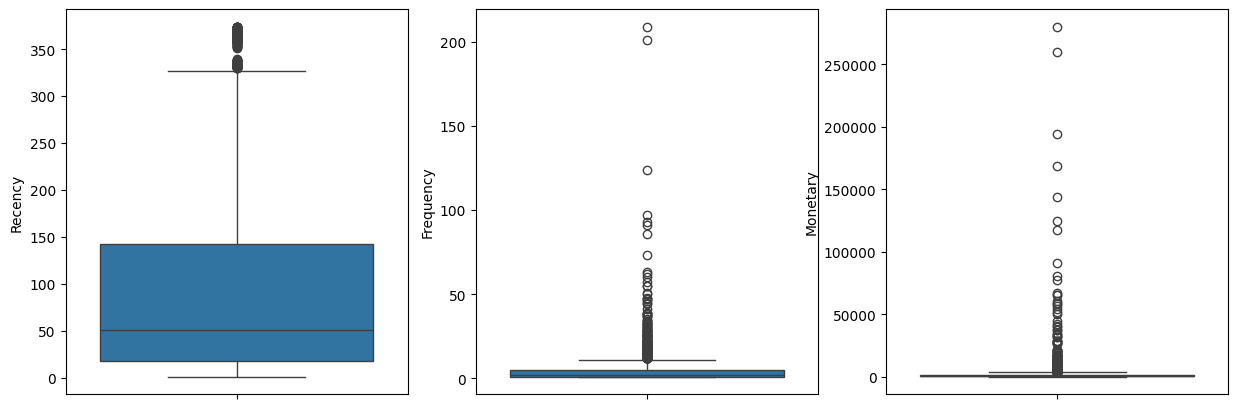

In [62]:
#outliers checking
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=rfm['Recency'])

plt.subplot(1,3,2)
sns.boxplot(y=rfm['Frequency'])

plt.subplot(1,3,3)
sns.boxplot(y=rfm['Monetary'])

plt.show()

In [64]:
#Log transformation and standardize the data
import numpy as np

rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])

rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])

rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log
)

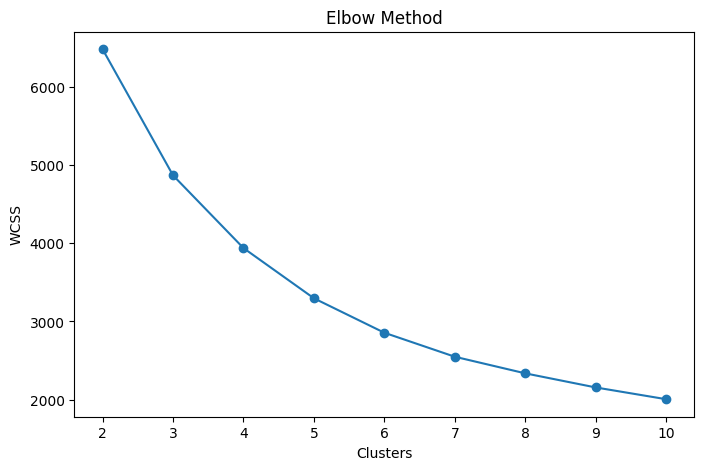

In [66]:
#find optimal K using Elbow method and plot the curve
from sklearn.cluster import KMeans

wcss = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [71]:
#train K-Means
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = (
    kmeans.fit_predict(rfm_scaled)
)
rfm['Cluster'].value_counts()

,count
Cluster,
2,963
3,956
0,827
5,650
1,619
4,323


In [69]:
rfm.shape[0]

4338

In [72]:
#cluster analysis
cluster_summary = (
    rfm.groupby('Cluster')
       .agg({
           'Recency':'mean',
           'Frequency':'mean',
           'Monetary':'mean'
       })
)

print(cluster_summary)

            Recency  Frequency      Monetary
Cluster                                     
0         36.532044   1.415961    317.670437
1         10.295638   4.116317   1298.955493
2        115.979232   2.591900   1023.607044
3        233.357741   1.167364    248.141705
4          7.362229  20.839009  13992.819288
5         42.587692   6.876923   3196.649708


In [73]:
#cluster mapping
segment_map = {

    0:'Champions',

    1:'Lost Customers',

    2:'Loyal Customers',

    3:'Regular Customers',

    4:'Potential Loyalists',

    5:'At Risk Customers'
}

rfm['Segment'] = (
    rfm['Cluster']
    .map(segment_map)
)

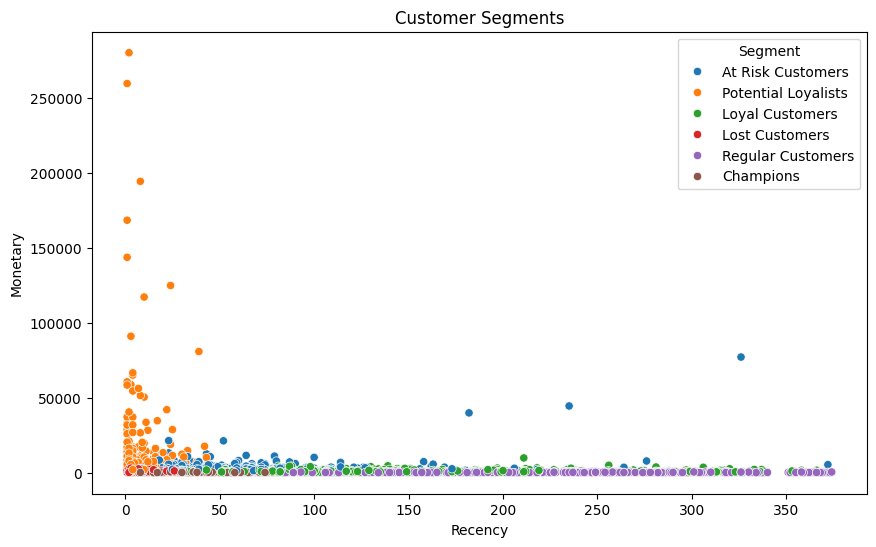

In [74]:
#visualize the clusters
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    palette='tab10'
)

plt.title("Customer Segments")

plt.show()

In [75]:
rfm['Segment'].value_counts()

,count
Segment,
Loyal Customers,963
Regular Customers,956
Champions,827
At Risk Customers,650
Lost Customers,619
Potential Loyalists,323


In [76]:
rfm.to_csv(
    "customer_segments.csv"
)

In [78]:
print(rfm.shape)

print(rfm['Cluster'].value_counts())

print(cluster_summary)

print(rfm['Segment'].value_counts())

(4338, 5)
Cluster
2    963
3    956
0    827
5    650
1    619
4    323
Name: count, dtype: int64
            Recency  Frequency      Monetary
Cluster                                     
0         36.532044   1.415961    317.670437
1         10.295638   4.116317   1298.955493
2        115.979232   2.591900   1023.607044
3        233.357741   1.167364    248.141705
4          7.362229  20.839009  13992.819288
5         42.587692   6.876923   3196.649708
Segment
Loyal Customers        963
Regular Customers      956
Champions              827
At Risk Customers      650
Lost Customers         619
Potential Loyalists    323
Name: count, dtype: int64
